In [95]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [96]:
# configura per importare da src
import sys
sys.path.append('./src')

In [19]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [ ]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [ ]:
import torch
from src.BOX.model import BoxHierarchyModel

box_model = BoxHierarchyModel()

In [97]:
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/box_models.pth"))

<All keys matched successfully>

In [ ]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [99]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [100]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CP.model import ConceptPredictor
from src.CHM.train import joint_training
import matplotlib.pyplot as plt
from src.CHM.test import test_joint_cbm
from src.utils.plot import plot_history, plot_test_results, plot_concept_error_heatmap, plot_concept_uncertainty_heatmap, plot_intervention_curve, analyze_misclassifications_concepts

### CBM with boxes

#### Train

In [101]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)

b_optimizer = torch.optim.Adam(list(b_cls.parameters()) + list(b_concept_predictor.parameters()), lr=0.0005)

lambda_concept = 1
gamma_hierarchy = 0.5

info = "boxes"

b_history = joint_training(
    classifier=b_cls,
    concept_predictor=b_concept_predictor,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    optimizer=b_optimizer,
    criterion_cls=b_cls_criterion,
    concept_heights=concept_heights,
    epochs=7,
    device=device,
    lambda_c=lambda_concept,
    gamma_h=gamma_hierarchy,
    info=info,
    bipolar=False,
)


========== Addestramento Joint CBM (con Logica Gerarchica) ==========
Epoca   1/7 | Acc Train: 78.6% | Acc Val: 89.0%
  TRAIN -> Tot: 1.3190 [Cls: 0.8486 | C: 0.3676 | H: 0.2057]
  VAL   -> Tot: 0.7928 [Cls: 0.3791 | C: 0.3029 | H: 0.2218]

Epoca   2/7 | Acc Train: 91.9% | Acc Val: 90.8%
  TRAIN -> Tot: 0.6590 [Cls: 0.2738 | C: 0.2811 | H: 0.2083]
  VAL   -> Tot: 0.7121 [Cls: 0.3305 | C: 0.2847 | H: 0.1938]

Epoca   3/7 | Acc Train: 93.9% | Acc Val: 91.0%
  TRAIN -> Tot: 0.5537 [Cls: 0.1952 | C: 0.2559 | H: 0.2051]
  VAL   -> Tot: 0.6642 [Cls: 0.3056 | C: 0.2555 | H: 0.2063]

Epoca   4/7 | Acc Train: 95.3% | Acc Val: 90.9%
  TRAIN -> Tot: 0.4947 [Cls: 0.1515 | C: 0.2427 | H: 0.2010]
  VAL   -> Tot: 0.6549 [Cls: 0.3100 | C: 0.2477 | H: 0.1943]

Epoca   5/7 | Acc Train: 96.1% | Acc Val: 91.5%
  TRAIN -> Tot: 0.4526 [Cls: 0.1191 | C: 0.2341 | H: 0.1988]
  VAL   -> Tot: 0.6497 [Cls: 0.3132 | C: 0.2392 | H: 0.1947]

Epoca   6/7 | Acc Train: 97.0% | Acc Val: 90.9%
  TRAIN -> Tot: 0.4223 [Cl

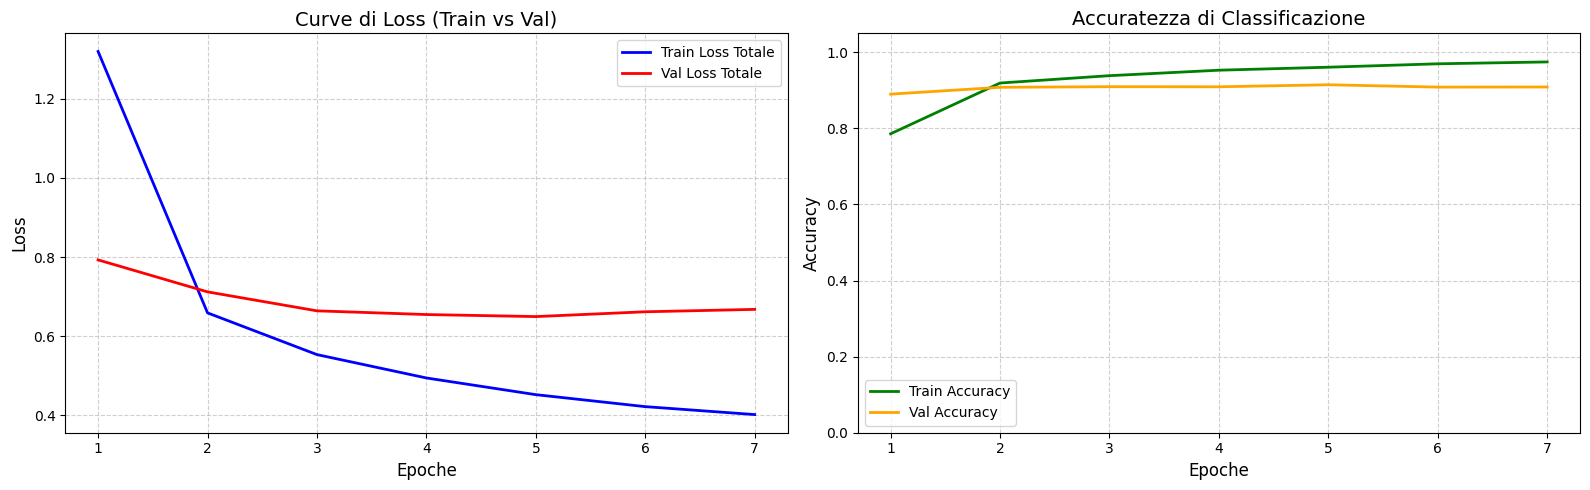

In [102]:
plot_history(b_history)

#### Test

In [103]:
accuracy, preds, labels, concept_preds, concept_trues, concept_probs = test_joint_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)


Inizio valutazione sul Test Set (Modalità Joint)...
Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.82% (6780/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       209
           1       0.94      0.89      0.92       170
           2       0.86      0.72      0.79        58
           3       0.76      0.68      0.72        38
           4       0.96      0.98      0.97       110
           5       0.98      0.82      0.89       149
           6       0.93      0.95      0.94       329
           7       0.90      0.92      0.91       207
           8       0.71      0.29      0.41        35
           9       0.75      0.91      0.82       100

   micro avg       0.91      0.88      0.89      1405
   macro avg       0.87      0.80      0.82      1405
weighted avg       0.91      0.88      0.89      1405



In [104]:
from src.CP.test import test_concept_predictor
criterion_cp = nn.BCEWithLogitsLoss()
_, _, _, _, _ =test_concept_predictor(b_concept_predictor, test_dataloader, class_concept_matrix, criterion_cp, device)

Inizio valutazione del Concept Predictor sul Test Set...
--------------------------------------------------
TEST CONCEPT PREDICTOR COMPLETATO
Test Loss: 0.2187
Test Concept Accuracy (Globale): 89.85%
--------------------------------------------------


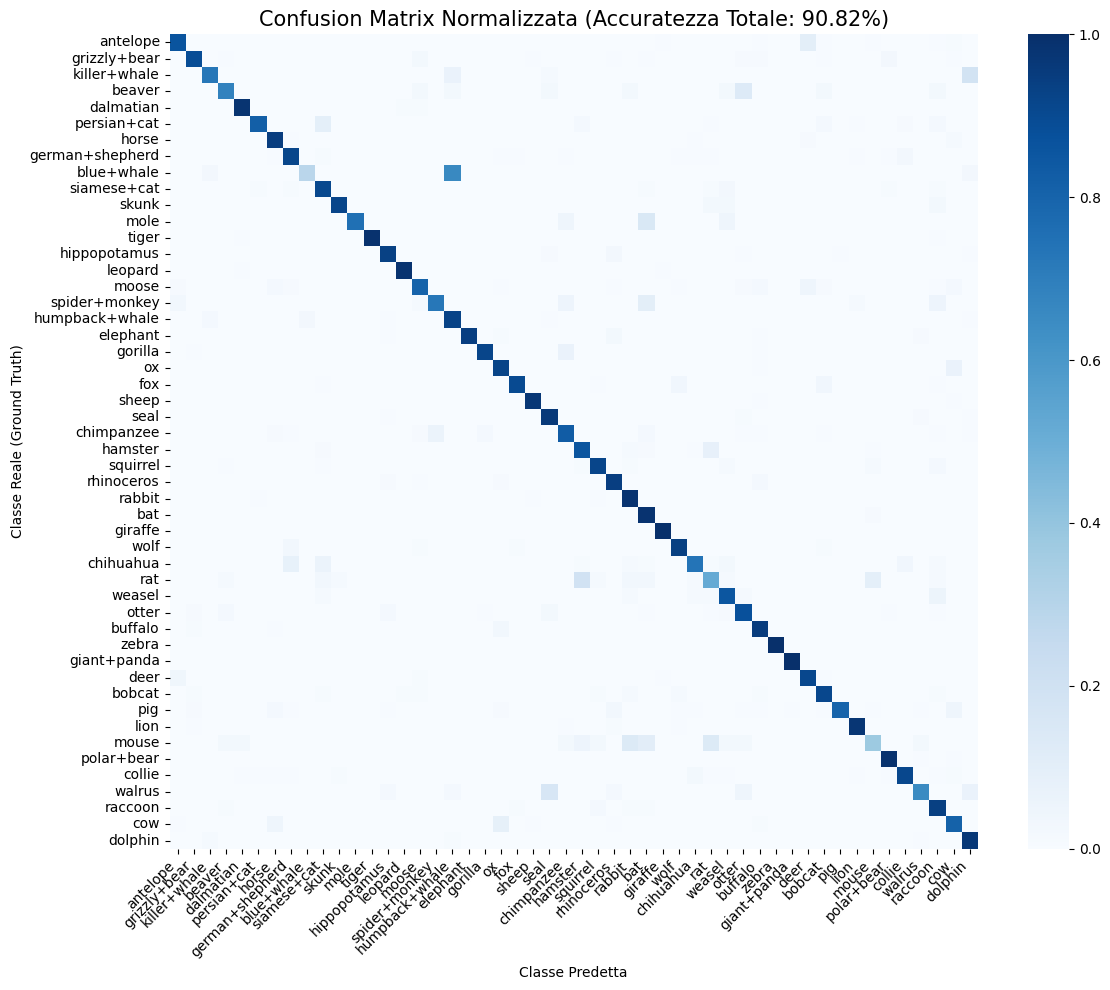


Analisi degli Errori Principali:
 - 24 volte: 'cow' è stato scambiato per 'ox'
 - 23 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 22 volte: 'antelope' è stato scambiato per 'deer'
 - 14 volte: 'persian+cat' è stato scambiato per 'siamese+cat'
 - 13 volte: 'hamster' è stato scambiato per 'rat'


In [105]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

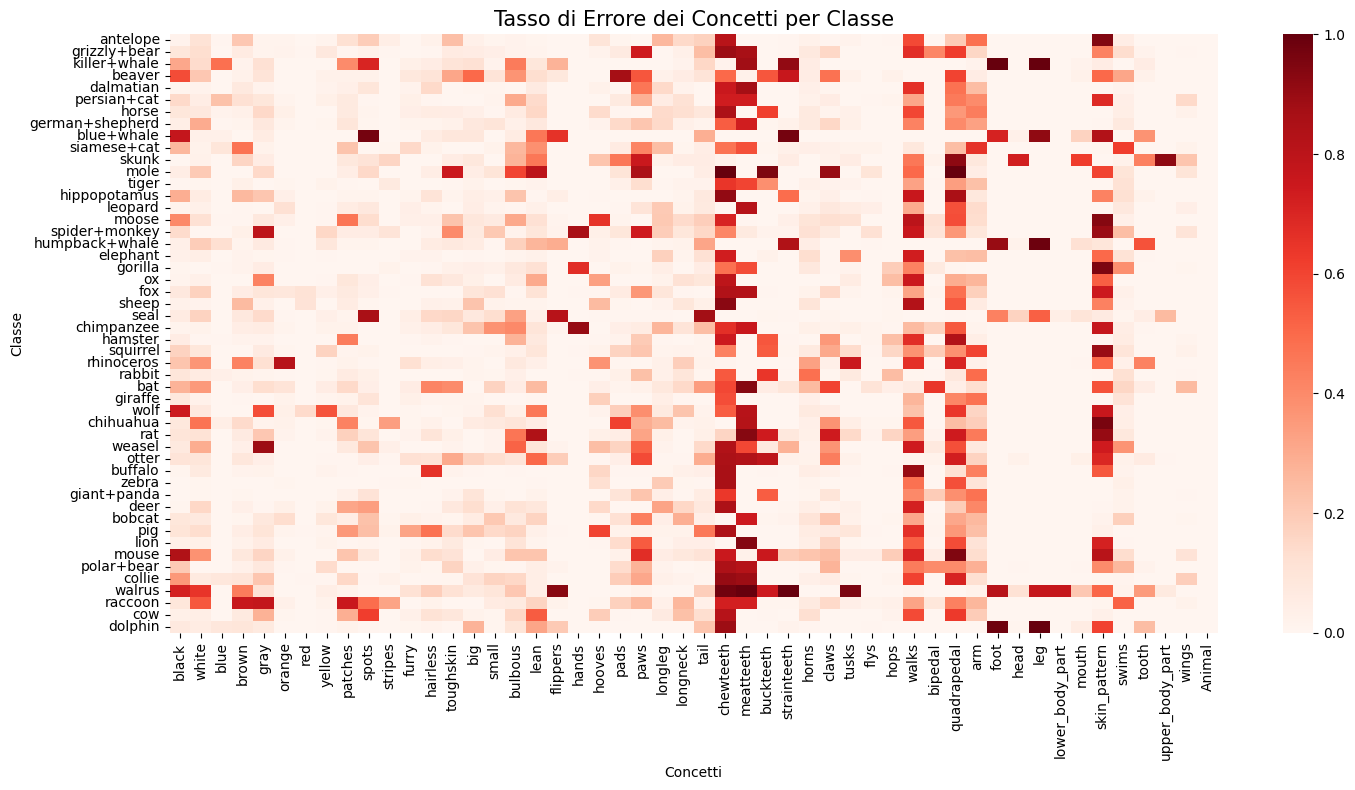

In [106]:
plot_concept_error_heatmap(labels, concept_preds, concept_trues, classes, concepts)

In [107]:
analyze_misclassifications_concepts(preds, labels, concept_preds, concept_trues, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'polar+bear'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [gray] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [tail] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [chewteeth] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [meatteeth] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [claws] Falso Positivo

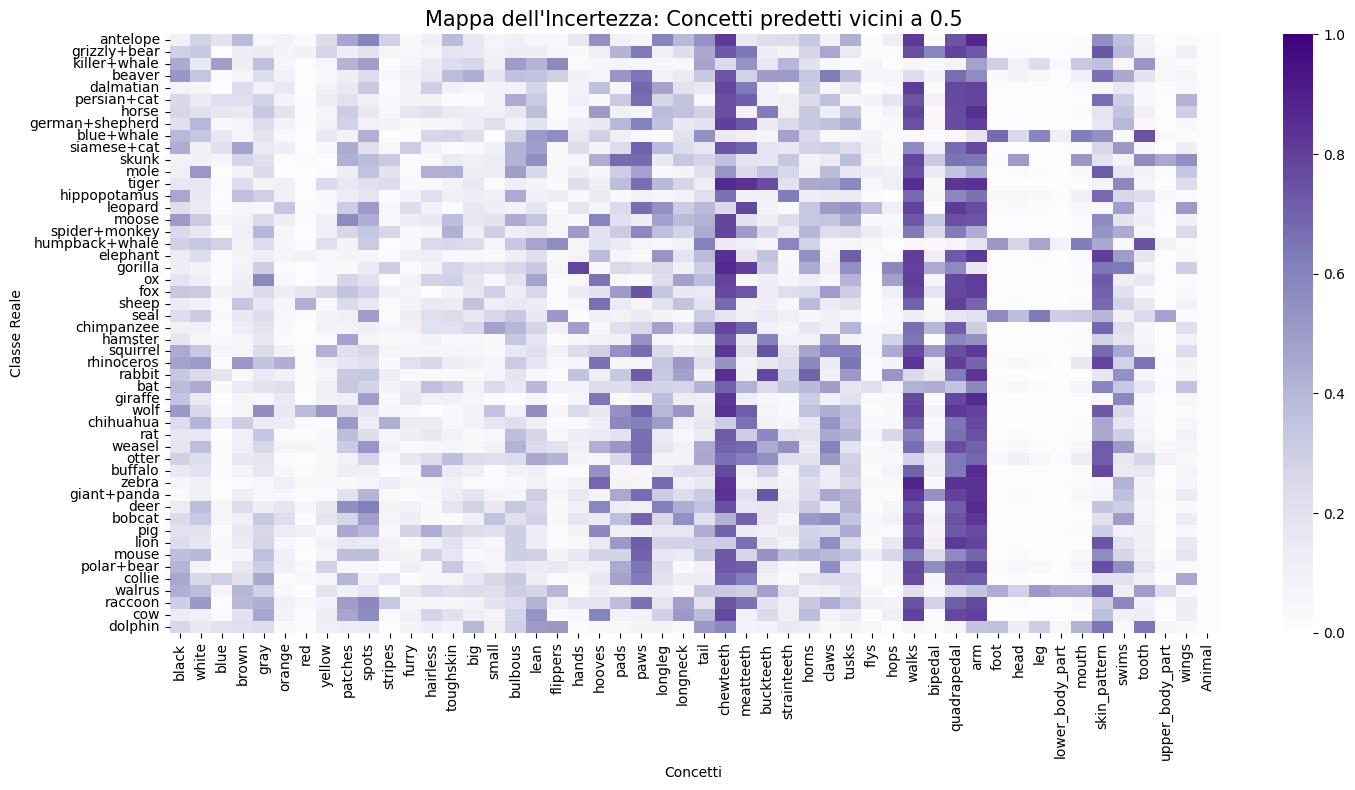

array([[8.93693194e-02, 2.84019411e-01, 1.97116137e-01, ...,
        2.04577297e-03, 2.14940775e-02, 2.80133856e-04],
       [2.91505188e-01, 3.31698418e-01, 3.75206233e-03, ...,
        8.65782797e-03, 1.08010031e-01, 5.48650241e-05],
       [4.44775552e-01, 1.58093452e-01, 4.87978548e-01, ...,
        3.67019661e-02, 2.14796141e-02, 1.03510662e-04],
       ...,
       [3.03702027e-01, 5.04132509e-01, 6.82439562e-03, ...,
        1.72463115e-02, 1.40598282e-01, 4.37112431e-05],
       [1.39320210e-01, 1.00894973e-01, 2.03752778e-02, ...,
        2.43188115e-03, 1.20909266e-01, 2.08834652e-04],
       [2.61989385e-01, 1.53634235e-01, 2.03377068e-01, ...,
        5.56614548e-02, 3.41729596e-02, 1.57742266e-04]])

In [108]:
plot_concept_uncertainty_heatmap(labels, concept_probs, class_names=classes, concept_names=concepts)

In [109]:
from src.utils.box import compute_stratified_concept_accuracy
stratified_acc = compute_stratified_concept_accuracy(concept_preds, concept_trues, concept_heights, id2concept)


 ACCURATEZZA CONCETTI STRATIFICATA PER ALTEZZA

► Livello  5 (Padri/Radici) | N. Concetti: 1 | Acc. Media: 100.00%
------------------------------------------------------------
    Animal                    : 100.00% 

► Livello  4 (Intermedio) | N. Concetti: 1 | Acc. Media: 98.82%
------------------------------------------------------------
    upper_body_part           :  98.82% 

► Livello  3 (Intermedio) | N. Concetti: 2 | Acc. Media: 99.20%
------------------------------------------------------------
    head                      :  98.97% 
    lower_body_part           :  99.44% 

► Livello  2 (Intermedio) | N. Concetti: 2 | Acc. Media: 95.65%
------------------------------------------------------------
    leg                       :  92.55% 
    mouth                     :  98.74% 

► Livello  1 (Intermedio) | N. Concetti: 6 | Acc. Media: 86.83%
------------------------------------------------------------
    skin_pattern              :  65.00%  <--- LEAKAGE SOSPETTO
    arm   

In [111]:
sm_acc, sm_preds, labels, sm_concept_preds, sm_concept_trues, sm_concept_probs = test_joint_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
    logical_smoothing=True,
    alpha=0.3,
)


Inizio valutazione sul Test Set (Modalità Joint)...
Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.74% (6774/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       209
           1       0.95      0.86      0.90       170
           2       0.86      0.72      0.79        58
           3       0.76      0.76      0.76        38
           4       0.96      0.98      0.97       110
           5       0.96      0.84      0.90       149
           6       0.94      0.94      0.94       329
           7       0.92      0.91      0.91       207
           8       0.75      0.26      0.38        35
           9       0.79      0.90      0.84       100

   micro avg       0.91      0.87      0.89      1405
   macro avg       0.88      0.80      0.83      1405
weighted avg       0.91      0.87      0.89      1405



In [112]:
from src.utils.box import compute_stratified_concept_accuracy
stratified_acc = compute_stratified_concept_accuracy(sm_concept_preds, sm_concept_trues, concept_heights, id2concept)


 ACCURATEZZA CONCETTI STRATIFICATA PER ALTEZZA

► Livello  5 (Padri/Radici) | N. Concetti: 1 | Acc. Media: 100.00%
------------------------------------------------------------
    Animal                    : 100.00% 

► Livello  4 (Intermedio) | N. Concetti: 1 | Acc. Media: 98.31%
------------------------------------------------------------
    upper_body_part           :  98.31% 

► Livello  3 (Intermedio) | N. Concetti: 2 | Acc. Media: 99.14%
------------------------------------------------------------
    head                      :  98.90% 
    lower_body_part           :  99.37% 

► Livello  2 (Intermedio) | N. Concetti: 2 | Acc. Media: 95.30%
------------------------------------------------------------
    leg                       :  92.27% 
    mouth                     :  98.34% 

► Livello  1 (Intermedio) | N. Concetti: 6 | Acc. Media: 90.13%
------------------------------------------------------------
    skin_pattern              :  66.46%  <--- LEAKAGE SOSPETTO
    arm   

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_optimizer = torch.optim.Adam(list(cp_cls.parameters()) + list(cp_concept_predictor.parameters()), lr=0.001)

cp_cls_history = joint_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,
    cp_criterion,
    concept_heights,
    EPOCHS, 
    device,
    lambda_concept,
    gamma_hierarchy,
    info,
    bipolar=False,
)

In [ ]:
plot_history(cp_cls_history)

#### Test

In [ ]:
cp_accuracy, cp_preds, cp_labels = test_joint_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [ ]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_optimizer = torch.optim.Adam(list(c_cls.parameters()) + list(c_concept_predictor.parameters()), lr=0.001)

c_cls_history = joint_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,
    c_criterion,
    concept_heights,
    EPOCHS, 
    device,
    lambda_concept,
    gamma_hierarchy,
    info,
    bipolar=False,
)

In [ ]:
from src.utils.plot import plot_history
plot_history(c_cls_history)

In [ ]:
c_accuracy, c_preds, c_labels = test_joint_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)